# ZDT2 Results

In [3]:
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_zdt2_front_true
from deap import benchmarks
import matplotlib.pyplot as plt
# 1. Parâmetros (Substituindo as antigas variáveis globais)
IND_SIZE = 30
NPOP = 100
NGEN = 200
NOBJ = 2
NUM_TABLES = int((1 << NOBJ))
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1] * NOBJ

# 2. Configurando o Toolbox para o DTLZ3
def func_zdt2(ind):
    return benchmarks.zdt2(ind)

# 3. Inicialização e Execução
toolbox = build_toolbox(func_zdt2, IND_SIZE, NPOP, NOBJ)
pop_inicial = toolbox.population()
for ind in pop_inicial:
    ind.fitness.values = toolbox.evaluate(ind)

tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)

pareto_real = generate_zdt2_front_true(10000, IND_SIZE)

# 5. Rodando o MEAMT
logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ)

[[0.06329133253138741, 0.9959942072264013], [0.6036685858288946, 0.6355842384833426], [0.8382680227987324, 0.2973067219531039], [0.4890704618223245, 0.7608100833728982], [0.287793279460153, 0.9171750282975702], [0.021347808005458657, 0.9995442710933621], [0.6902358097310979, 0.5235745269648556], [0.5280129088544446, 0.7212023680830679], [0.4685088671082276, 0.7804994414409652], [0.9981319602019771, 0.003732590023358684], [0.41947655761527225, 0.8240394176112412], [0.6757956160028475, 0.5433002853913318], [0.9935387429496307, 0.012880766258067555], [0.5423198776191359, 0.7058891503391654], [0.79367285019463, 0.3700834068639325], [0.2653909478734121, 0.9295676447868518], [0.589388078676748, 0.6526216927137315], [0.4720880915185922, 0.7771328338463332], [0.7784082653685997, 0.3940805724058476], [0.6520069006027481, 0.574887001566398], [0.35494837453927175, 0.8740116514119288], [0.7926232592808111, 0.3717483688470641], [0.847492185771998, 0.2817569950554012], [0.12777263801495342, 0.983674

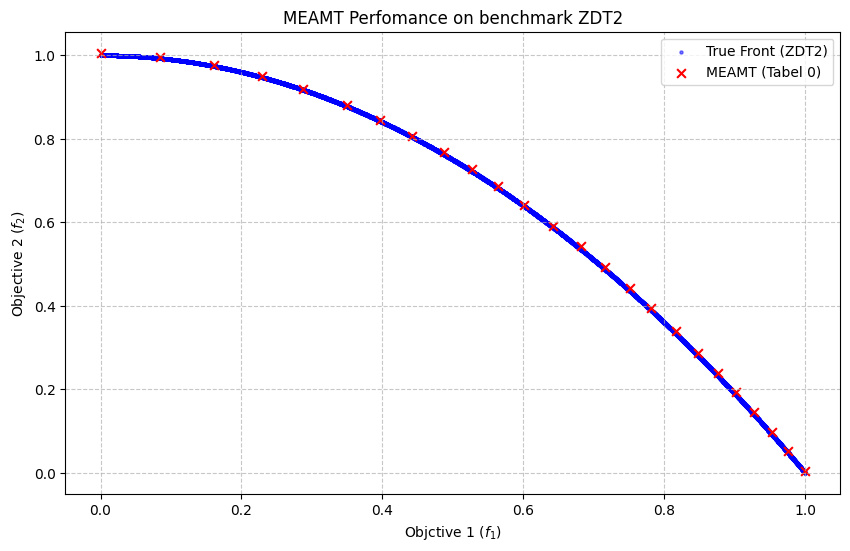

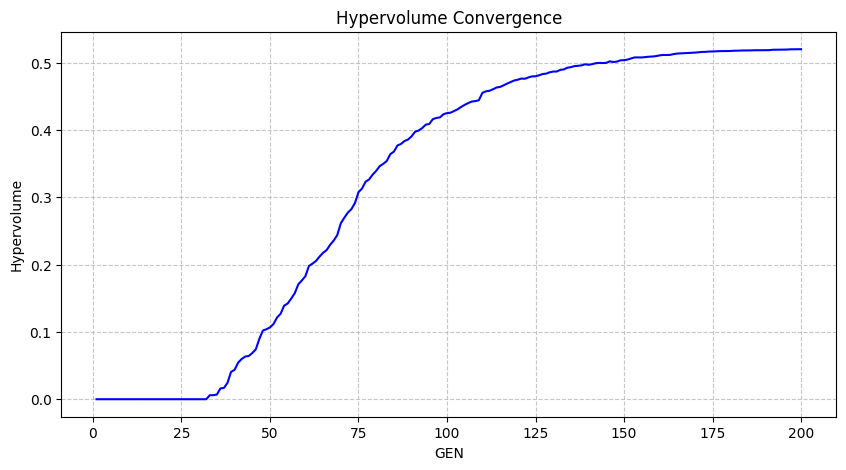

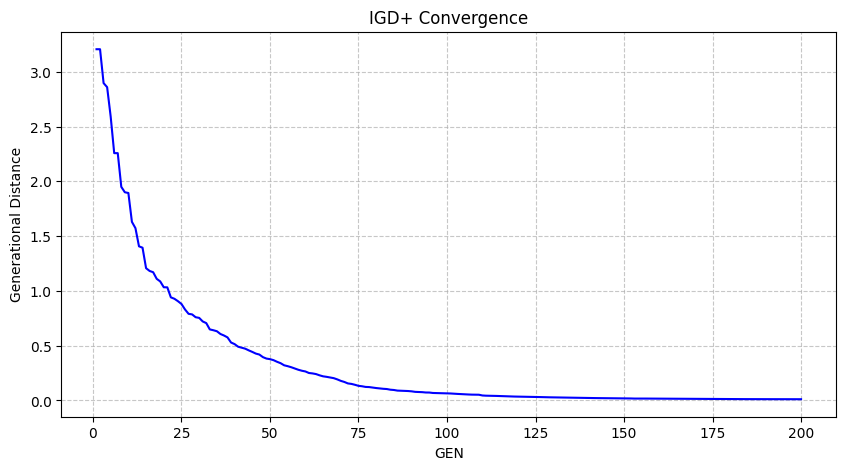

In [4]:
print(pareto_real)
f1_approx = [ind.fitness.values[0] for ind in tabelas[0]]
f2_approx = [ind.fitness.values[1] for ind in tabelas[0]]

f1_true = [linha[0] for linha in pareto_real]
f2_true = [linha[1] for linha in pareto_real]


plt.figure(figsize=(10, 6))


plt.scatter(f1_true, f2_true, color='blue', s=5, alpha=0.5, label='True Front (ZDT2)')


plt.scatter(f1_approx, f2_approx, color='red', marker='x', s=40, label='MEAMT (Tabel 0)')

plt.title("MEAMT Perfomance on benchmark ZDT2")
plt.xlabel("Objctive 1 ($f_1$)")
plt.ylabel("Objective 2 ($f_2$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Exibe o gráfico
plt.show()

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()